\# Exploring TensorFlow

TensorFlow is a library for building and training machine learning models — things like image classifiers, text generators, and recommendation systems. Under the hood, "training a model" almost always boils down to the same idea: start with some numbers (weights), see how wrong your predictions are, and nudge the numbers to be a little less wrong, over and over.

This notebook is a first tour of the pieces that make that possible:

- **Tensors** — how TensorFlow stores and moves numbers around.
- **Variables** — the numbers that are allowed to change during training.
- **Automatic differentiation** — how TensorFlow figures out *which direction* to nudge those numbers.
- **A tiny training loop** — putting the above together to actually learn something, without using any of the higher-level "just call `.fit()`" shortcuts, so you can see what's happening underneath.

Before running, select the **TensorFlow** conda environment as this notebook's kernel (top-right kernel picker in VS Code).

## 1. Setup

Import TensorFlow and check the version plus whether it sees a GPU.

GPUs make training big models much faster because they can do thousands of numeric operations in parallel, which is exactly what tensor math needs. But on native Windows, TensorFlow 2.11+ can only use the CPU — you'll likely see `GPUs available: []` and a warning about that below, and that's expected, not a bug. Everything in this notebook is small enough to run comfortably on CPU; GPUs only start to matter once you're training larger models on more data.

In [2]:
import numpy as np
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPUs available: []


## 2. Tensors: the core data structure

Think of a tensor as just a grid of numbers, and "dimensions" as how many directions that grid extends in:

- A **scalar** is a single number (0 dimensions) — e.g. `7`.
- A **vector** is a list of numbers (1 dimension) — e.g. `[1, 2, 3]`.
- A **matrix** is a grid of numbers (2 dimensions) — rows and columns.
- Beyond that, TensorFlow just keeps stacking dimensions — a color image is typically a 3D tensor (height × width × color channels), and a batch of images is 4D (batch × height × width × channels).

A `tf.Tensor` behaves a lot like a NumPy array — same idea of shape and dtype (the type of number it holds, like `int32` or `float32`) — but it's built to also run on a GPU/TPU and to be tracked by TensorFlow's automatic differentiation (more on that in section 5). The one thing to remember: tensors are **immutable**. You never edit one in place — every operation (adding, reshaping, slicing) hands you back a brand new tensor.

In [4]:
scalar = tf.constant(7)
vector = tf.constant([1.0, 2.0, 3.0])
matrix = tf.constant([[1, 2], [3, 4]])

for name, t in [("scalar", scalar), ("vector", vector), ("matrix", matrix)]:
    print(f"{name}: shape={t.shape}, dtype={t.dtype}\n{t}\n")

scalar: shape=(), dtype=<dtype: 'int32'>
7

vector: shape=(3,), dtype=<dtype: 'float32'>
[1. 2. 3.]

matrix: shape=(2, 2), dtype=<dtype: 'int32'>
[[1 2]
 [3 4]]



Now some basic math on tensors. Note there are two different kinds of multiplication below, which trips people up early on:

- **Element-wise (`*`)** — multiplies matching positions together, like overlaying two grids and multiplying each pair of cells independently. The inputs and output are all the same shape.
- **Matrix multiply (`@`, or `tf.matmul`)** — the "real" linear-algebra matrix multiplication, where each output cell is a sum of products across a row and a column. This is the operation that powers neural network layers (a layer's output is essentially `inputs @ weights + bias`).

In [5]:
# Basic operations behave like NumPy
a = tf.constant([[1, 2], [3, 4]])
b = tf.constant([[5, 6], [7, 8]])

print("a + b:\n", a + b)
print("\nelement-wise a * b:\n", a * b)
print("\nmatrix multiply a @ b:\n", a @ b)  # equivalent to tf.matmul(a, b)

a + b:
 tf.Tensor(
[[ 6  8]
 [10 12]], shape=(2, 2), dtype=int32)

element-wise a * b:
 tf.Tensor(
[[ 5 12]
 [21 32]], shape=(2, 2), dtype=int32)

matrix multiply a @ b:
 tf.Tensor(
[[19 22]
 [43 50]], shape=(2, 2), dtype=int32)


## 3. Tensors interoperate with NumPy

You can convert freely between the two: `tf.constant(numpy_array)` wraps a NumPy array as a tensor, and `.numpy()` unwraps a tensor back into a NumPy array. They even share the same underlying memory when possible, so converting is cheap.

This matters in practice because you'll rarely start with data already in `tf.Tensor` form — you'll load a CSV with pandas, an image with PIL, or an array with NumPy, and then hand it to TensorFlow. Being comfortable moving between the two formats is an everyday part of the workflow, not just a one-off trick.

In [6]:
np_array = np.array([[1.0, 2.0], [3.0, 4.0]])

tensor_from_np = tf.constant(np_array)       # NumPy -> Tensor
back_to_np = tensor_from_np.numpy()          # Tensor -> NumPy

print(type(tensor_from_np), "\n", tensor_from_np)
print(type(back_to_np), "\n", back_to_np)

<class 'tensorflow.python.framework.ops.EagerTensor'> 
 tf.Tensor(
[[1. 2.]
 [3. 4.]], shape=(2, 2), dtype=float64)
<class 'numpy.ndarray'> 
 [[1. 2.]
 [3. 4.]]


## 4. Variables: mutable state

`tf.constant` tensors can't be changed in place — they're meant for values that don't change, like fixed input data. But a model's weights need to update thousands of times during training, and creating a brand new tensor at every single step would be wasteful and awkward to track.

`tf.Variable` is TensorFlow's answer: a container that holds a tensor's worth of numbers but can be updated in place with `.assign(...)`. Every trainable weight and bias in a neural network is a `tf.Variable` under the hood — when people say a model has "175 billion parameters," they mean 175 billion numbers living in `tf.Variable`s like this one.

In [7]:
weight = tf.Variable(3.0)
print("initial:", weight.numpy())

weight.assign(5.0)
print("after assign:", weight.numpy())

weight.assign_add(1.0)
print("after assign_add:", weight.numpy())

initial: 3.0
after assign: 5.0
after assign_add: 6.0


## 5. Automatic differentiation with `GradientTape`

Here's the core question training has to answer, over and over: "if I nudge this weight up a little, does my error get better or worse, and by how much?" That's exactly what a **derivative** (or gradient, for multiple variables) tells you — the slope of the loss with respect to a variable.

You could work these out by hand with calculus, but for a model with millions of weights that's not realistic. Instead, TensorFlow watches every operation you perform on a variable while inside a `with tf.GradientTape() as tape:` block — like a tape recorder logging each step. Afterwards, `tape.gradient(y, x)` replays that tape backwards, applying the chain rule automatically, to tell you exactly how `y` changes as `x` changes. This "record forward, then compute backward" process is called **backpropagation**, and it's the single most important trick that makes deep learning practical.

Example: for $y = x^2$, calculus tells us $\frac{dy}{dx} = 2x$, so at $x = 3$ we expect a gradient of $6$. Below, TensorFlow computes that same answer without us ever writing the derivative ourselves.

In [8]:
x = tf.Variable(3.0)

with tf.GradientTape() as tape:
    y = x ** 2

dy_dx = tape.gradient(y, x)
print("y =", y.numpy())
print("dy/dx =", dy_dx.numpy())

y = 9.0
dy/dx = 6.0


## 6. Putting it together: a tiny training loop

This is where sections 2–5 come together into the pattern behind essentially all model training. Every training loop repeats these steps:

1. **Predict** — run the current variables through the model to get a prediction (the "forward pass").
2. **Measure the error** — compare the prediction to the true answer using a **loss function**. A smaller loss means better predictions.
3. **Compute gradients** — inside a `GradientTape`, ask "which direction should each variable move to make the loss smaller?"
4. **Update the variables** — take a small step in that direction. The step size is called the **learning rate**; too big and training overshoots and gets unstable, too small and it takes forever.
5. Repeat for many **epochs** (passes over the data) until the loss stops improving much.

Below we generate points from `y = 2x + 1` with a bit of random noise added (to make it feel like real, imperfect data), then let the model discover `w ≈ 2` and `b ≈ 1` purely by repeating steps 1–4 above — no calculus done by hand, no Keras layers, just tensors, variables, and gradients. This is precisely what `model.fit()` does for you in Keras, just automated and generalized to arbitrarily complex models.

In [9]:
# Synthetic data: y = 2x + 1, plus a little noise
np.random.seed(0)
x_train = np.linspace(-1, 1, 100).astype(np.float32)
y_train = 2 * x_train + 1 + np.random.normal(0, 0.1, size=x_train.shape).astype(np.float32)

# Parameters to learn
w = tf.Variable(0.0)
b = tf.Variable(0.0)
learning_rate = 0.1

def loss_fn(x, y):
    y_pred = w * x + b
    return tf.reduce_mean(tf.square(y_pred - y))  # mean squared error

for epoch in range(50):
    with tf.GradientTape() as tape:
        loss = loss_fn(x_train, y_train)

    dw, db = tape.gradient(loss, [w, b])
    w.assign_sub(learning_rate * dw)
    b.assign_sub(learning_rate * db)

    if epoch % 10 == 0:
        print(f"epoch {epoch:2d}: loss={loss.numpy():.4f}, w={w.numpy():.3f}, b={b.numpy():.3f}")

print(f"\nlearned: w={w.numpy():.3f}, b={b.numpy():.3f} (target: w=2.0, b=1.0)")

epoch  0: loss=2.3622, w=0.135, b=0.201
epoch 10: loss=0.3493, w=1.070, b=0.920
epoch 20: loss=0.0903, w=1.533, b=0.997
epoch 30: loss=0.0297, w=1.762, b=1.005
epoch 40: loss=0.0149, w=1.875, b=1.006

learned: w=1.926, b=1.006 (target: w=2.0, b=1.0)


Look at the printed epochs: `loss` steadily drops while `w` climbs toward `2.0` and `b` climbs toward `1.0` — that's gradient descent working exactly as described above. It won't land on the target numbers exactly, both because of the random noise we added to the data and because we stopped after a fixed number of epochs rather than training to convergence.

## What's next: from manual gradients to Keras

You just implemented gradient descent by hand — this is exactly what `model.fit()` does under the hood in Keras (TensorFlow's high-level, batteries-included API). Understanding the manual version means the "magic" of `.fit()` is no longer magic: it's just this loop, wrapped up neatly. The rest of this notebook rebuilds the same idea using the higher-level tools, then applies it to a real dataset:

- **`tf.keras.Sequential`/layers** — describe *what* the model looks like instead of manually managing `w`/`b` and writing the update step yourself.
- **`tf.keras.optimizers`** (e.g. `Adam`, `SGD`) — swap the plain "subtract learning_rate times gradient" step for smarter, adaptive optimizers that converge faster and more reliably.
- **`tf.data.Dataset`** — efficient data pipelines (batching, shuffling, prefetching) for feeding real, often much larger, datasets into training.
- **MNIST** — a classic "hello world" of image classification: 70,000 small images of handwritten digits (0–9). Same loop, bigger model, real data.

## 7. The same model, the Keras way

`tf.keras` is TensorFlow's high-level API for building models. Instead of declaring `w` and `b` yourself and writing the gradient-update step by hand, you describe the model's *shape* and Keras handles variables, gradients, and updates internally.

A single `Dense` layer with 1 output unit and 1 input feature computes exactly `y = w * x + b` — it's the same linear model as before, just expressed declaratively. `model.compile(...)` picks the optimizer and loss function, and `model.fit(...)` runs the same predict → measure error → compute gradients → update loop from section 6, automatically, for as many epochs as you ask.

In [10]:
keras_model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=(1,))
])

keras_model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1), loss="mse")

history = keras_model.fit(x_train, y_train, epochs=50, verbose=0)

learned_w, learned_b = keras_model.layers[0].get_weights()
print(f"final loss: {history.history['loss'][-1]:.4f}")
print(f"learned: w={learned_w[0][0]:.3f}, b={learned_b[0]:.3f} (target: w=2.0, b=1.0)")

final loss: 0.0102
learned: w=1.988, b=1.007 (target: w=2.0, b=1.0)


## 8. Optimizers: smarter update rules

In sections 6 and 7, the update rule was the simplest possible one — plain gradient descent (`SGD`): always take a step of the same fixed size, scaled by the gradient. It works, but it's sensitive to the learning rate and can be slow to converge on harder problems.

**Optimizers** are more sophisticated update rules that adjust the step size on the fly. `Adam` is the most commonly used default: it keeps a running average of recent gradients (momentum) and adapts the effective learning rate per-parameter based on how those gradients have been behaving. In practice this usually means faster, more stable convergence with less manual tuning of the learning rate.

Below, the exact same model/data trains with `Adam` instead of `SGD`. Compare the loss after just 10 epochs to how far `SGD` got after 10 epochs in section 6 (`loss=0.3493`) — Adam typically gets much further, much faster.

In [9]:
adam_model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=(1,))
])

adam_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse")

adam_history = adam_model.fit(x_train, y_train, epochs=50, verbose=0)

for epoch in [0, 9, 19, 49]:
    print(f"epoch {epoch:2d}: loss={adam_history.history['loss'][epoch]:.4f}")

learned_w, learned_b = adam_model.layers[0].get_weights()
print(f"\nlearned: w={learned_w[0][0]:.3f}, b={learned_b[0]:.3f} (target: w=2.0, b=1.0)")

epoch  0: loss=4.0865
epoch  9: loss=0.0359
epoch 19: loss=0.0117
epoch 49: loss=0.0102

learned: w=1.984, b=1.006 (target: w=2.0, b=1.0)


## 9. `tf.data.Dataset`: feeding data efficiently

So far we've handed `model.fit()` a complete NumPy array of 100 points, which comfortably fits in memory all at once. Real datasets are often far too large for that — millions of images, for instance — so you need a pipeline that reads and prepares data incrementally instead of loading everything up front.

`tf.data.Dataset` is that pipeline. A few pieces matter most for training:

- **`.batch(n)`** — group examples into chunks of `n`. Models are trained on batches rather than one example at a time (faster, more stable gradients) or the whole dataset at once (too much memory).
- **`.shuffle(buffer_size)`** — randomize the order examples are seen in, so the model doesn't learn spurious patterns from data ordering.
- **`.prefetch(...)`** — overlap loading the *next* batch with computing on the *current* one, so the GPU/CPU doesn't sit idle waiting on data.

`model.fit()` accepts a `Dataset` directly in place of raw NumPy arrays, which is what makes this useful in practice rather than just an abstraction.

In [10]:
dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
dataset = dataset.shuffle(buffer_size=len(x_train)).batch(16).prefetch(tf.data.AUTOTUNE)

# Peek at one batch to see the shapes/type coming out of the pipeline
for batch_x, batch_y in dataset.take(1):
    print("batch_x shape:", batch_x.shape)
    print("batch_y shape:", batch_y.shape)

# fit() accepts the Dataset directly -- no need to pass x_train/y_train separately
dataset_model = tf.keras.Sequential([tf.keras.layers.Dense(units=1, input_shape=(1,))])
dataset_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse")
dataset_model.fit(dataset, epochs=20, verbose=0)

learned_w, learned_b = dataset_model.layers[0].get_weights()
print(f"\nlearned from Dataset: w={learned_w[0][0]:.3f}, b={learned_b[0]:.3f} (target: w=2.0, b=1.0)")

batch_x shape: (16,)
batch_y shape: (16,)


C:\Users\Administrator\anaconda3\envs\TensorFlow\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(



learned from Dataset: w=1.983, b=1.000 (target: w=2.0, b=1.0)


## 10. A real dataset: classifying MNIST digits

Everything so far predicted a single continuous number (**regression**). MNIST is a **classification** problem instead: given a 28×28 grayscale image of a handwritten digit, predict which of 10 classes (`0`–`9`) it is. That difference changes a couple of things about the model:

- **Output layer**: instead of 1 output number, we need 10 — one score per possible digit. A `softmax` activation turns those 10 scores into probabilities that sum to 1.
- **Loss function**: instead of mean squared error, we use `sparse_categorical_crossentropy`, which measures how far the predicted probability distribution is from "100% confident in the correct digit."
- **Metric**: we'll also track `accuracy` (percent of images classified correctly) since that's easier to interpret than a raw loss number.

Everything else — compile, fit, the predict → measure error → compute gradients → update loop — is identical to what you've already seen.


       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step


  229376/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


  770048/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


 1769472/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


 2703360/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

...


 9142272/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


10190848/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


10993664/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


train images: (60000, 28, 28) train labels: (60000,)
test images:  (10000, 28, 28) test labels:  (10000,)


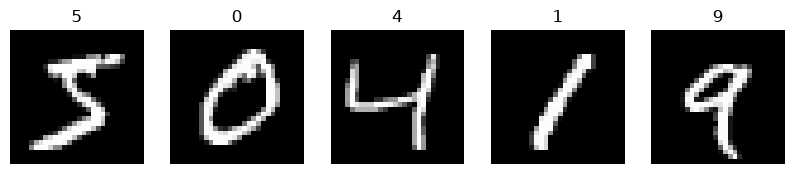

In [11]:
import matplotlib.pyplot as plt

(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()

print("train images:", mnist_x_train.shape, "train labels:", mnist_y_train.shape)
print("test images: ", mnist_x_test.shape, "test labels: ", mnist_y_test.shape)

# Pixel values are 0-255; scaling to 0-1 helps training converge faster and more reliably
mnist_x_train = mnist_x_train / 255.0
mnist_x_test = mnist_x_test / 255.0

# Peek at a few examples
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(mnist_x_train[i], cmap="gray")
    ax.set_title(str(mnist_y_train[i]))
    ax.axis("off")
plt.show()

In [12]:
mnist_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),   # 28x28 image -> a flat vector of 784 numbers
    tf.keras.layers.Dense(128, activation="relu"),   # a hidden layer that learns intermediate features
    tf.keras.layers.Dense(10, activation="softmax"), # 10 output probabilities, one per digit
])

mnist_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

mnist_model.summary()

C:\Users\Administrator\anaconda3\envs\TensorFlow\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
mnist_history = mnist_model.fit(
    mnist_x_train, mnist_y_train,
    epochs=5,
    validation_split=0.1,   # hold out 10% of training data to sanity-check for overfitting each epoch
)

test_loss, test_accuracy = mnist_model.evaluate(mnist_x_test, mnist_y_test, verbose=0)
print(f"\ntest accuracy: {test_accuracy:.4f}")

Epoch 1/5



   1/1688 ━━━━━━━━━━━━━━━━━━━━ 51:51 2s/step - accuracy: 0.0312 - loss: 2.3640


  17/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4908 - loss: 1.8284  


  34/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6140 - loss: 1.4661


  51/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6740 - loss: 1.2288

...


1620/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9859 - loss: 0.0470


1649/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9859 - loss: 0.0469


1678/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9859 - loss: 0.0469


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9858 - loss: 0.0471 - val_accuracy: 0.9783 - val_loss: 0.0769



test accuracy: 0.9772


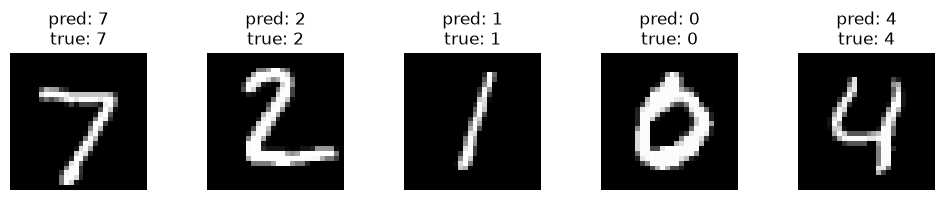

In [14]:
# Look at a handful of actual predictions vs. the true labels
predictions = mnist_model.predict(mnist_x_test[:5], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)  # pick the digit with the highest probability

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(mnist_x_test[i], cmap="gray")
    ax.set_title(f"pred: {predicted_labels[i]}\ntrue: {mnist_y_test[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Where to go from here

With ~97-98% test accuracy from a tiny two-layer network trained for a few seconds on CPU, you've now been through the full loop that underlies almost every TensorFlow project: tensors and variables hold the numbers, `GradientTape`/optimizers figure out how to improve them, `tf.data` feeds them efficiently, and Keras layers assemble it all into models you can describe in a few lines. A few directions to keep exploring:

- **Convolutional layers (`Conv2D`)** — instead of flattening the image immediately, CNNs look at local patches of pixels first. They're the standard architecture for image tasks and would likely push MNIST accuracy above 99%.
- **Overfitting and regularization** — try more epochs and watch `val_accuracy` (from `validation_split` above) start to lag behind training accuracy; then look into `Dropout` layers and early stopping as ways to address it.
- **Saving/loading models** — `model.save(...)` / `tf.keras.models.load_model(...)`, so training doesn't have to happen every time you want to use a model.
- **TensorBoard** — TensorFlow's built-in tool for visualizing training curves, model graphs, and more over time, instead of reading printed loss values.